In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [62]:
df = pd.read_csv('covid2.csv')

df.sample(5)

,age,gender,fever,cough,city,has_covid
22301,51,Male,104.5,Mild,Hyderabad,No
54376,81,Female,101.0,Mild,Delhi,No
43319,90,Male,98.7,Mild,Kolkata,Yes
6298,67,Male,103.6,Moderate,Chennai,No
98843,78,Female,100.2,Mild,Bangalore,Yes


In [63]:
df.shape

(100000, 6)

In [64]:
df.isnull().sum()

age              0
gender           0
fever            0
cough        20211
city             0
has_covid        0
dtype: int64

In [65]:
df.describe()

,age,fever
count,100000.000000,100000.000000
mean,49.938050,101.006028
std,28.651368,2.311457
min,1.000000,97.000000
25%,25.000000,99.000000
50%,50.000000,101.000000
75%,75.000000,103.000000
max,99.000000,105.000000


In [66]:

df['cough'].value_counts() 

cough
Mild        39937
Moderate    24921
Severe      14931
Name: count, dtype: int64

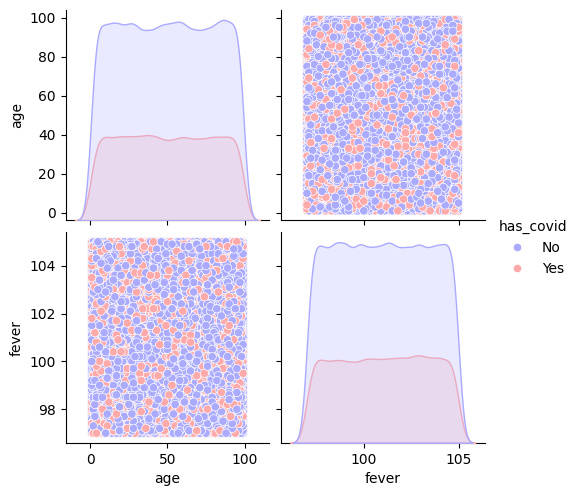

In [67]:
sns.pairplot(df,hue='has_covid',palette='bwr')

### Outliers Treatment

In [68]:
df.head(2)

,age,gender,fever,cough,city,has_covid
0,52,Female,99.7,Mild,Chennai,No
1,93,Male,98.5,Moderate,Bangalore,No


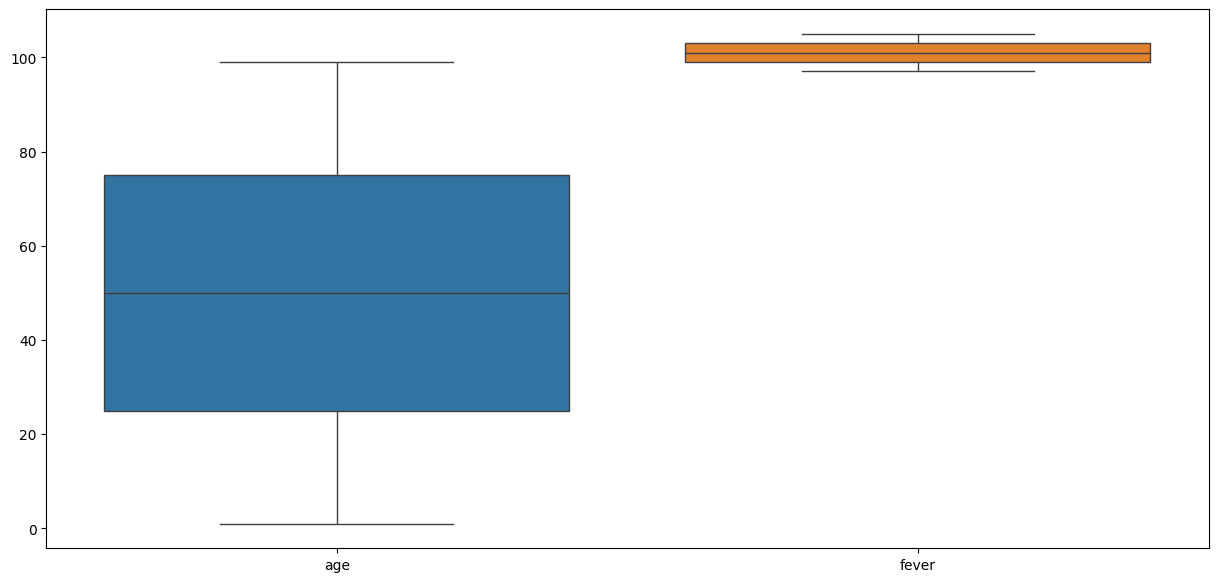

In [69]:
plt.figure(figsize=(15,7))
sns.boxplot(data = df[['age','fever']])
plt.show()

## there is no outliers in the given data so we can proceed further

In [70]:
x = df[['age', 'gender', 'cough', 'city', 'fever']]
y = df[['has_covid']]

In [71]:
X_train, X_test, y_train, y_test =  train_test_split(x,y,test_size=0.1,random_state=42)

### We will encode the label into numerical values(0,1)

In [73]:
le = LabelEncoder()

In [74]:

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
print(y_train.shape,
y_test.shape)

(90000,) (10000,)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [75]:
from sklearn.compose import ColumnTransformer

In [76]:
# Pipeline for 'cough': Impute then Encode
cough_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['Mild', 'Moderate', 'Severe']]))
])

# Full ColumnTransformer
transformer = ColumnTransformer(transformers=[
    ('cough_pipeline', cough_pipeline, ['cough']),
    ('onehot', OneHotEncoder(drop='first'), ['gender', 'city'])
], remainder='passthrough')

In [77]:
tr1 = LogisticRegression(max_iter=500)

In [78]:
pipe = Pipeline([
    ('transformer', transformer),('tr1',tr1)
])

In [55]:
pipe.fit(X_train,y_train)

,steps,"[('transformer', ...), ('tr1', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cough_pipeline', ...), ('onehot', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
y_pred=pipe.predict(X_test)
y_pred


array([0, 0, 0, ..., 0, 0, 0], shape=(10000,))

In [58]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [59]:
accuracy_score(y_test,y_pred)


0.7002

In [60]:

scores = cross_val_score(pipe, x, y, cv=20, scoring='accuracy')

print("Cross-validation accuracy scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/uti

Cross-validation accuracy scores: [0.7012 0.7012 0.7012 0.7012 0.7012 0.7012 0.7012 0.7012 0.7012 0.7012
 0.7012 0.7012 0.7012 0.7012 0.7012 0.7012 0.7012 0.7012 0.7012 0.701 ]
Mean accuracy: 0.7011900000000001
Standard deviation: 4.358898943542613e-05
